# Dynamic Optimised Theta Model (DOTM)

This notebook demonstrates the **Dynamic Optimised Theta Model (DOTM)** forecaster in the `aeon` toolkit. DOTM is a modern, state-space reformulation of the classical [Theta method](theta.ipynb). Where classical Theta fixes the trend line and the combination weights, DOTM *optimises* the theta parameter and *updates the long-run line dynamically* as new data arrives, and it adds optional automatic seasonal adjustment.

DOTM was proposed by Fiorucci et al. (2016), who showed that the optimised Theta family can be written as innovations state-space models. The dynamic variant (DOTM) was the engine behind several of the strongest pure statistical entries in the M4 competition.

> Fiorucci, J. A., Pellegrini, T. R., Louzada, F., Petropoulos, F., & Koehler, A. B. (2016). Models for optimising the theta method and their relationship to state space models. *International Journal of Forecasting*, 32(4), 1151-1161. https://doi.org/10.1016/j.ijforecast.2016.02.005


## 1. How the DOTM algorithm works

Recall the classical Theta method (see the [Theta notebook](theta.ipynb)): the series is split into a *theta line* that exaggerates the local curvature, and a linear *trend line*, which are smoothed and recombined. DOTM keeps that idea but makes three changes.

**1. A single smoothed level with an optimised theta.** The level $\ell_t$ is the simple exponential smoothing (SES) recursion on the series,

$$\ell_t = \alpha\, y_t + (1-\alpha)\, \ell_{t-1},$$

with smoothing parameter $\alpha$. The curvature emphasis is controlled by $\theta \ge 1$ through

$$\omega = 1 - \frac{1}{\theta}.$$

$\theta=2$ recovers the classical weighting ($\omega = 0.5$); larger $\theta$ gives more weight to the long-run line.

**2. A *dynamic* long-run line.** Instead of a single OLS regression on time fitted
once, DOTM maintains a regression line $(a_t + b_t\,t)$ whose intercept $a_t$ and
slope $b_t$ are **updated recursively** at every step. Using the running mean $\bar{y}_t$ of the series:

$$b_t = \frac{(t-1)\,b_{t-1} + 6\,(y_t - \bar{y}_{t-1})/(t+1)}{t+2}, \qquad a_t = \bar{y}_t - b_t\,\frac{t+2}{2}.$$

So the trend the model extrapolates is re-estimated as the series evolves rather than frozen at fit time. This is the "dynamic" in DOTM.

**3. Forecast = level + discounted long-run line.** The $h$-step forecast from the end of the series ($n$ observations) is

$$\hat{y}_{n+h} = \ell_n + \omega\left[a_n (1-\alpha)^{n+h-1} + b_n\,\frac{1-(1-\alpha)^{n+h}}{\alpha}\right].$$

The level provides the anchor; the bracketed term adds the (discounted) contribution of the dynamic trend line.

**Estimation.** The free parameters $(\ell_0, \alpha, \theta)$ are fitted by minimising the in-sample one-step sum of squared errors with a bounded Nelder-Mead optimiser. Any of them can also be fixed by the user.

**Seasonality.** DOTM is non-seasonal at its core. When `season_length > 1` (and seasonality is detected/requested) the series is first decomposed with a classical multiplicative or additive decomposition, the DOTM core is fit to the seasonally adjusted series, and the seasonal pattern is added back (seasonal-naive) to the forecast.


## 2. Parameters and their effects

- **`theta`** (default `None` -> estimated, bounded `>= 1`): curvature / long-run weight via $\omega = 1 - 1/\theta$. `theta=1` gives $\omega=0$ (pure SES, a flat forecast); `theta=2` reproduces classical Theta; large `theta` pushes $\omega \to 1$ and leans heavily on the extrapolated trend line.
- **`alpha`** (default `None` -> estimated in `(0.1, 0.99)`): SES smoothing. Small `alpha` = smooth, slowly adapting level; large `alpha` = reactive level that tracks recent observations.
- **`initial_level`** (default `None` -> estimated): the SES seed $\ell_0$.
- **`season_length`** (default `1`): seasonal period. `1` means no seasonality. Set to e.g. `12` for monthly data with a yearly cycle.
- **`seasonal_test`** (default `"auto"`): `"auto"` runs an ACF test and deseasonalises only when seasonality is detected; `True` always deseasonalises (given enough data); `False` never does.
- **`decomposition_type`** (default `"multiplicative"`): how the seasonal component is removed. Multiplicative falls back to additive automatically for non-positive or unstable series.
- **`alpha_bounds`, `theta_bounds`, `initial_level_bounds`**: optimiser bounds for the estimated parameters.

The most consequential choices in practice are whether to model seasonality (`season_length`) and whether to fix vs estimate `theta`/`alpha`. We explore both below.


## 3. Forecasting with DOTM

### Imports


In [12]:
import matplotlib.pyplot as plt
import numpy as np

from aeon.datasets import load_airline
from aeon.forecasting.stats import DOTM, Theta

### Example: fit, `forecast` and `iterative_forecast`

`forecast` returns the single one-step-ahead value, while `iterative_forecast` rolls the model forward to produce a multi-step horizon. Both fit the model to the series you pass in.

To show DOTM doing something a flat or straight-line forecaster could not, we use a series with **curvature** (accelerating growth). Because DOTM re-estimates its trend line dynamically, its forecast *bends* to follow the curve. We overlay the classical [Theta](theta.ipynb) forecast, which is a closed-form straight line, to make the difference visible.


One-step-ahead forecast: 55.171


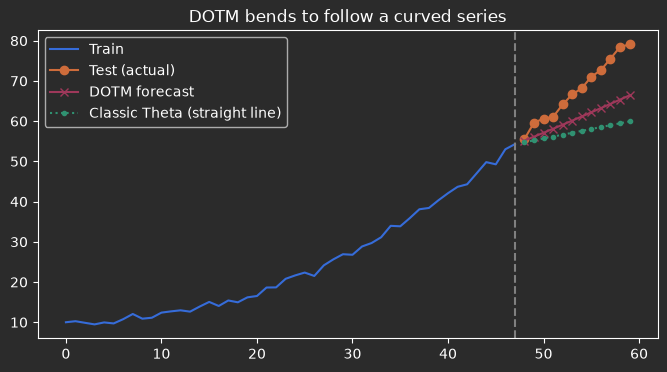

DOTM  test MSE: 64.64
Theta test MSE: 141.38
DOTM forecast increments: 0.963 -> 1.063 (growing => convex forecast, not a straight line)


In [13]:
# A series with curvature: accelerating (convex) growth + noise
rng = np.random.default_rng(7)
n_points = 60
time = np.arange(n_points)
y = 10 + 0.02 * time**2 + rng.normal(scale=0.8, size=n_points)

# Hold out the last 12 observations as a test set
y_train, y_test = y[:-12], y[-12:]

# Fit and forecast one step ahead
forecaster = DOTM()
forecaster.fit(y_train)
y_pred_1 = forecaster.forecast(y_train)
print(f"One-step-ahead forecast: {y_pred_1:.3f}")

# Forecast across the whole test horizon
y_preds = forecaster.iterative_forecast(y_train, prediction_horizon=len(y_test))

# Classical Theta for comparison (closed-form straight-line forecast)
theta_preds = Theta().iterative_forecast(y_train, prediction_horizon=len(y_test))

# Plot train, test actuals, and both forecasts
test_time = np.arange(len(y_train), len(y))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(y_train)), y_train, label="Train")
plt.plot(test_time, y_test, marker="o", label="Test (actual)")
plt.plot(test_time, y_preds, marker="x", label="DOTM forecast")
plt.plot(
    test_time,
    theta_preds,
    marker=".",
    linestyle=":",
    label="Classic Theta (straight line)",
)
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
plt.legend()
plt.title("DOTM bends to follow a curved series")
plt.show()

print(f"DOTM  test MSE: {np.mean((y_test - y_preds) ** 2):.2f}")
print(f"Theta test MSE: {np.mean((y_test - theta_preds) ** 2):.2f}")
incr = np.diff(y_preds)
print(
    f"DOTM forecast increments: {incr[0]:.3f} -> {incr[-1]:.3f} "
    f"(growing => convex forecast, not a straight line)"
)

Unlike a pure linear-trend series (where DOTM and Theta both give an essentially straight forecast), here the DOTM forecast **accelerates** to track the convex trend: its step increments *grow* across the horizon. Classical Theta can only extrapolate a straight line, so it undershoots the curve and has a larger test error. DOTM achieves this because its long-run trend line $(a_t, b_t)$ keeps being re-estimated as the series evolves (see the worked example below).

**Why is DOTM still well short of the actual at the end of the horizon?** DOTM bends in the right direction, but it does not *fit a quadratic* — at heart it is still a linear-trend-plus-smoothing model. Its extrapolated slope is the dynamic line slope $b_n$, which here is about $0.94$ per step. That value is essentially the **average** slope over the whole training window, but for an accelerating series the slope is constantly increasing: by the end of training the local slope is already $\approx 1.8$, and across the test region the series actually rises by $\approx 2.1$ per step. DOTM's feedback recursion (feeding each forecast back in to nudge $a_t, b_t$) adds only mild curvature on top of that averaged slope, lifting its mean step to about $1.0$ — still less than half the true rate. So the forecast keeps falling further behind the longer the horizon, ending roughly $13$ units below the final actual. This is expected: a sustained quadratic trend violates the locally-linear assumption shared by the whole Theta family, so any of these models will under-extrapolate a genuine acceleration. The remedy is not a different Theta variant but either a shorter horizon (where the linear approximation holds) or a model with an explicit damped or curved trend.


DOTM estimates the parameters during `fit`. We can inspect what it found:


In [14]:
print(f"initial_level_ : {forecaster.initial_level_:.4f}")
print(f"alpha_         : {forecaster.alpha_:.4f}")
print(f"theta_         : {forecaster.theta_:.4f}")
print(f"dynamic line   : a_={forecaster.a_:.4f}, b_={forecaster.b_:.4f}")
print(f"final level_   : {forecaster.level_:.4f}")

initial_level_ : -91.8522
alpha_         : 0.9142
theta_         : 9999907220.7788
dynamic line   : a_=1.5183, b_=0.9428
final level_   : 54.1393


### Can we tune DOTM to fit this series better?

Short answer: **not via DOTM's own parameters.** Notice from the fit above that `alpha_` is already high ($\approx 0.91$) and `theta_` has been driven to its upper bound, i.e. $\omega = 1 - 1/\theta \approx 1$. In other words the optimiser is *already* putting essentially all the weight on the long-run trend line and letting the level track recent points as fast as it can. The estimated configuration is the most curvature DOTM can produce on this data.

You can confirm there is nothing better to find by fixing the parameters yourself:

| Setting | Test MSE |
|---|---|
| **default (all estimated)** | **64.6** |
| `theta=2` (classical) | 137.7 |
| `theta=8` | 80.3 |
| `theta=50` | 67.0 |
| `alpha=0.5` | 166.8 |
| `alpha=0.99` | 137.7 |

Every fixed choice is *worse than, or at best converges up to*, the default: as `theta` is pushed larger the error falls toward the $64.6$ the optimiser already reached on its own. Lowering `theta` or `alpha` only flattens the forecast and makes things worse. There is no knob in DOTM that controls trend *curvature* directly, because the dynamic line $a_t + b_t t$ is structurally linear — so no parameter setting turns it into a quadratic fit.

The settings that genuinely help live **outside** the model:

- **Transform the series.** A quadratic becomes linear under a square root, so fitting DOTM to $\sqrt{y}$ and squaring the forecast back drops the test MSE from $64.6$ to about $18$. Matching the transformation to the curvature (log for exponential growth, etc.) is far more effective than tuning `alpha`/`theta`.
- **Shorten the horizon.** The locally-linear approximation is fine over a few steps and only degrades far out. Forecasting $3$ steps instead of $12$ gives a test MSE around $8$. If you need long horizons on a strongly curved series, re-fit and roll forward in short blocks.
- **Use a model with an explicit trend shape** (e.g. a damped-trend ETS, or a regression with a quadratic term) when the curvature is genuinely part of the signal rather than noise.

DOTM's defaults are already doing the best this model can here; closing the remaining gap is a question of *preprocessing and horizon*, not hyper-parameters.


### One-step vs multi-step: the cost of not knowing the future

It is tempting to think the undershoot above comes from *freezing the fitted parameters* (`alpha_`, `theta_`, `initial_level_`) after `fit`. It does not. Two different things could update after `fit`:

- the **parameters** (`alpha_`, `theta_`, ...), which are frozen, and
- the **recursion states** (the level $\ell_t$ and the dynamic line $a_t, b_t$), which *do* keep updating during `iterative_forecast` — but they are fed the model's **own forecasts** as stand-in observations, not the ground truth.

When the slope state $b_t$ is updated from the model's own under-accelerating forecasts it barely grows, so the curvature it can express is limited and the error compounds with the horizon. If instead the *true* values are revealed before each step (a rolling **one-step-ahead** forecast), $b_t$ keeps climbing with the real accelerating data and the forecasts track the curve closely — even with the parameters left frozen. The cell below shows all three cases.


In [ ]:
h = len(y_test)

# (1) multi-step: states are fed the model's OWN forecasts
f = DOTM()
f.fit(y_train)
p_multi = f.iterative_forecast(y_train, prediction_horizon=h)

# (2) rolling one-step, FROZEN params: the true value is revealed
#     before each step, so the states are rebuilt from ground truth
p_one = np.array([f.forecast(y[: len(y_train) + k]) for k in range(h)])

# (3) rolling one-step, REFIT each step: re-estimate params on the
#     growing window (only possible because we are revealing the truth)
p_refit = []
for k in range(h):
    ctx = y[: len(y_train) + k]
    g = DOTM()
    g.fit(ctx)
    p_refit.append(g.forecast(ctx))
p_refit = np.array(p_refit)

print(
    f"(1) multi-step, own forecasts fed   MSE = "
    f"{np.mean((y_test - p_multi) ** 2):6.1f}"
)
print(
    f"(2) one-step, frozen params, truth  MSE = "
    f"{np.mean((y_test - p_one) ** 2):6.1f}"
)
print(
    f"(3) one-step, refit each step       MSE = "
    f"{np.mean((y_test - p_refit) ** 2):6.1f}"
)

Two things stand out. **(2) vs (3): re-estimating the parameters barely matters** — the error is essentially the same whether or not we refit, confirming the undershoot is *not* about frozen parameters. **(1) vs (2): feeding ground truth into the states collapses the error** with the very same frozen parameters, so it is entirely about what the state recursion is fed.

Crucially, case (2)/(3) is **not something you can do in real forecasting**: revealing the true value before each step *is* knowing the future. That number is really the **one-step-ahead** error (an easier task), while case (1) is the honest **multi-step** error. The gap between them is the unavoidable cost of forecasting without the ground truth, and it grows with the horizon — which is exactly why a recursive method looks so much weaker on a strongly accelerating series than its one-step error would suggest.


## 4. Worked example: how the recursion produces a forecast

To understand DOTM we reproduce its in-sample one-step fitted values by hand and confirm they match the library. We fix the parameters so the recursion is fully determined, then walk through the three states: the SES level $\ell_t$, and the dynamic line $(a_t, b_t)$.


In [2]:
# Fix parameters so the recursion is deterministic
alpha, theta = 0.3, 2.0
omega = 1.0 - 1.0 / theta
yw = 10 + 0.3 * np.arange(40) + np.random.default_rng(0).normal(scale=0.8, size=40)

model = DOTM(initial_level=yw[0] / 2, alpha=alpha, theta=theta)
model.fit(yw)

# --- Manual reproduction of the DOTM recursion ---
n = len(yw)
ell = alpha * yw[0] + (1 - alpha) * (yw[0] / 2)  # seeded SES level
mean_y, a, b = yw[0], yw[0], 0.0
fitted = np.empty(n)
fitted[0] = yw[0]
for i in range(n - 1):
    power = (1 - alpha) ** (i + 1)
    slope_term = b * (1 - (1 - alpha) ** (i + 2)) / alpha
    fitted[i + 1] = ell + omega * (a * power + slope_term)  # one-step fitted
    # update states
    ell = alpha * yw[i + 1] + (1 - alpha) * ell
    prev_mean = mean_y
    mean_y = ((i + 1) * mean_y + yw[i + 1]) / (i + 2)
    b = (i * b + 6 * (yw[i + 1] - prev_mean) / (i + 2)) / (i + 3)
    a = mean_y - b * (i + 3) / 2

print(
    "Max abs diff vs library fitted_values_:",
    np.max(np.abs(fitted - model.fitted_values_)),
)
print(f"Manual final dynamic line: a={a:.4f}, b={b:.4f}")
print(f"Library final dynamic line: a_={model.a_:.4f}, b_={model.b_:.4f}")

Max abs diff vs library fitted_values_: 3.552713678800501e-15
Manual final dynamic line: a=9.5216, b=0.3063
Library final dynamic line: a_=9.5216, b_=0.3063


The manual recursion matches the library to floating-point precision. The key takeaway is that the dynamic line $(a_t, b_t)$ is *re-estimated at every step* from the running mean. We can watch it evolve, which is exactly what distinguishes DOTM from the fixed OLS line of classical Theta.


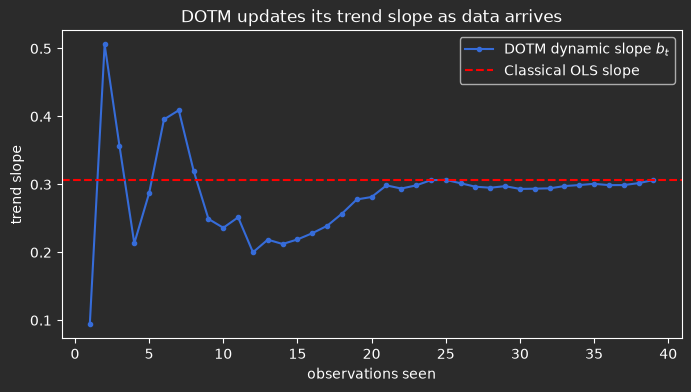

In [3]:
# Track the slope b_t as data arrives, vs the single classical OLS slope
b_track, mean_y, a, b = [], yw[0], yw[0], 0.0
for i in range(n - 1):
    prev_mean = mean_y
    mean_y = ((i + 1) * mean_y + yw[i + 1]) / (i + 2)
    b = (i * b + 6 * (yw[i + 1] - prev_mean) / (i + 2)) / (i + 3)
    a = mean_y - b * (i + 3) / 2
    b_track.append(b)

ols_slope = np.polyfit(np.arange(n), yw, 1)[0]
plt.figure(figsize=(8, 4))
plt.plot(range(1, n), b_track, marker=".", label="DOTM dynamic slope $b_t$")
plt.axhline(ols_slope, color="red", linestyle="--", label="Classical OLS slope")
plt.xlabel("observations seen")
plt.ylabel("trend slope")
plt.title("DOTM updates its trend slope as data arrives")
plt.legend()
plt.show()

## 5. The effect of `theta`

$\theta$ controls $\omega = 1 - 1/\theta$, the weight on the extrapolated long-run line. With `theta=1` the forecast is a flat SES level; as `theta` grows the forecast picks up more of the trend slope.


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(time, y, label="Series", color="black", alpha=0.4)
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
for th in [1.0, 1.5, 2.0, 5.0]:
    f = DOTM(alpha=0.3, theta=th)
    preds = f.iterative_forecast(y_train, prediction_horizon=12)
    plt.plot(range(len(y_train), len(y)), preds, marker="o", label=f"theta={th}")
plt.legend()
plt.title("Effect of theta on the DOTM forecast (alpha fixed at 0.3)")
plt.show()

## 6. Seasonality: airline passengers

The classical Theta method has no seasonal component and does poorly on strongly seasonal data. DOTM's optional decomposition step lets it handle this. We compare the default (non-seasonal) DOTM against DOTM with `season_length=12` on the classic airline series.


In [ ]:
y_air = load_airline().squeeze()
y_train, y_test = y_air[:-24], y_air[-24:]

dotm_plain = DOTM()  # season_length=1, no seasonality
pred_plain = dotm_plain.iterative_forecast(y_train, prediction_horizon=24)

dotm_seasonal = DOTM(season_length=12)
pred_seasonal = dotm_seasonal.iterative_forecast(y_train, prediction_horizon=24)

time = np.arange(len(y_air))
plt.figure(figsize=(9, 4))
plt.plot(time, y_air, label="Series", color="black")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
fut = np.arange(len(y_train), len(y_air))
plt.plot(fut, pred_plain, marker=".", label="DOTM (non-seasonal)")
plt.plot(fut, pred_seasonal, marker=".", label="DOTM (season_length=12)")
plt.legend()
plt.title("DOTM on airline passengers: seasonality matters")
plt.show()

mse_plain = np.mean((y_test - pred_plain) ** 2)
mse_seasonal = np.mean((y_test - pred_seasonal) ** 2)
print(f"MSE non-seasonal : {mse_plain:.1f}")
print(f"MSE seasonal     : {mse_seasonal:.1f}")
print(f"deseasonalised_  : {dotm_seasonal.deseasonalised_}")
print(f"decomposition    : {dotm_seasonal.decomposition_type_}")

The seasonal model captures the yearly cycle and dramatically reduces the error. We can inspect the seasonal factors it learned (length 12, one per month). For multiplicative decomposition they are ratios centred on 1.0.


In [ ]:
factors = dotm_seasonal.seasonal_factors_
plt.figure(figsize=(8, 3))
plt.bar(range(1, 13), factors)
plt.axhline(1.0, color="grey", linestyle="--")
plt.xlabel("season position")
plt.ylabel("multiplicative factor")
plt.title("Learned seasonal factors")
plt.show()

## 7. Summary

- **DOTM** is a dynamic, optimised state-space version of the Theta method.
- It estimates the smoothing parameter `alpha`, the curvature parameter `theta`, and the initial level by minimising in-sample one-step SSE; any can be fixed.
- Unlike classical Theta, its long-run trend line $(a_t, b_t)$ is **updated recursively** as the series grows.
- It adds optional **seasonal decomposition** (`season_length`, `seasonal_test`, `decomposition_type`), which makes it usable on seasonal series where classical Theta fails.
- For a side-by-side view of the simpler method DOTM generalises, see the [Theta notebook](theta.ipynb).

### Reference

Fiorucci, J. A., Pellegrini, T. R., Louzada, F., Petropoulos, F., & Koehler, A. B. (2016). Models for optimising the theta method and their relationship to state space models. *International Journal of Forecasting*, 32(4), 1151-1161.
